In [ ]:
#Libraries importation
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


#Loading data


In [ ]:
from google.colab import files
uploaded = files.upload()
df_train = pd.read_csv("train.csv")
print(f"Dataset loaded: {df_train.shape[0]} rows and {df_train.shape[1]} columns")
print("\nFirst 5 rows:")
df_train.head()

Saving train.csv to train.csv
Dataset loaded: 1460 rows and 81 columns

First 5 rows:


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


Data infos(columns , types , count..)




In [ ]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

#Searching for  Missing Values


In [82]:
missing = df_train.isnull().sum()

missing = missing[missing > 0]

missing.sort_values(ascending=False)

,0
PoolQC,1453
MiscFeature,1406
Alley,1369
Fence,1179
MasVnrType,872
FireplaceQu,690
LotFrontage,259
GarageType,81
GarageYrBlt,81
GarageFinish,81


# Searching for duplicates


In [ ]:
duplicates = df_train.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")
if duplicates > 0:
    print("\nDuplicate rows:")
    print(df_train[df_train.duplicated()])



Number of duplicate rows: 0


# Percentage of missing values

In [ ]:

print("=== Missing Values Analysis ===")
missing = df_train.isnull().sum()
missing_pct = (missing / len(df_train)) * 100

missing_df = pd.DataFrame({
    'Missing_Count': missing,
    'Percentage': missing_pct
})
missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)
print(missing_df)

=== Missing Values Analysis ===
              Missing_Count  Percentage
PoolQC                 1453   99.520548
MiscFeature            1406   96.301370
Alley                  1369   93.767123
Fence                  1179   80.753425
MasVnrType              872   59.726027
FireplaceQu             690   47.260274
LotFrontage             259   17.739726
GarageType               81    5.547945
GarageYrBlt              81    5.547945
GarageFinish             81    5.547945
GarageQual               81    5.547945
GarageCond               81    5.547945
BsmtExposure             38    2.602740
BsmtFinType2             38    2.602740
BsmtQual                 37    2.534247
BsmtCond                 37    2.534247
BsmtFinType1             37    2.534247
MasVnrArea                8    0.547945
Electrical                1    0.068493



#Missing Data Visulaization





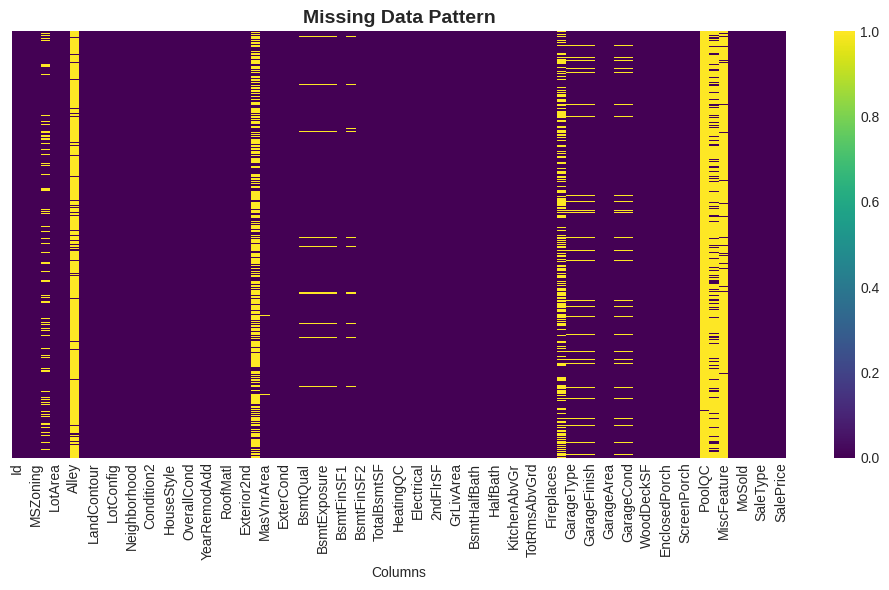

In [ ]:

plt.figure(figsize=(10, 6))
sns.heatmap(df_train.isnull(), cbar=True, yticklabels=False, cmap='viridis')
plt.title('Missing Data Pattern', fontsize=14, fontweight='bold')
plt.xlabel('Columns')
plt.tight_layout()
plt.show()




**Handling missing values**



**1) Dropping some columns**




In [ ]:
df_clean = df_clean.drop('PoolQC', axis=1)
df_clean = df_clean.drop('MiscFeature', axis=1)
df_clean = df_clean.drop('Alley', axis=1)
df_clean = df_clean.drop('Fence', axis=1)


In [ ]:
df_clean.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope',
       'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle',
       'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle',
       'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea',
       'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond',
       'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC',
       'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
       'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath',
       'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd',
       'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt',
       'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond',
       'PavedDrive', 'WoodD


**Categorical Data Encoding:**

*   Identify categorical columns (object type)
*   Apply Label Encoding





In [ ]:
from sklearn.preprocessing import LabelEncoder

categorical_cols = df_clean.select_dtypes(include=['object']).columns

le = LabelEncoder()
for col in categorical_cols:
    df_clean[col] = le.fit_transform(df_clean[col])

print("Label encoding applied to all object-type columns in df_clean_train.")
print("Updated df_clean_train info:")
df_clean.info()
df_clean.head()

Label encoding applied to all object-type columns in df_clean_train.
Updated df_clean_train info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Columns: 237 entries, Id to SaleCondition_Partial
dtypes: float64(3), int64(234)
memory usage: 2.6 MB


,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,1,60,65.0,8450,7,5,2003,2003,196.0,706,...,0,0,0,0,1,0,0,0,1,0
1,2,20,80.0,9600,6,8,1976,1976,0.0,978,...,0,0,0,0,1,0,0,0,1,0
2,3,60,68.0,11250,7,5,2001,2002,162.0,486,...,0,0,0,0,1,0,0,0,1,0
3,4,70,60.0,9550,7,5,1915,1970,0.0,216,...,0,0,0,0,1,0,0,0,0,0
4,5,60,84.0,14260,8,5,2000,2000,350.0,655,...,0,0,0,0,1,0,0,0,1,0


**KNN  Imputation for some columns **

*   Select only numerical columns for KNN imputation demo
*   Initialize KNN imputer with 5 neighbors
*   Apply imputation







In [ ]:

from sklearn.impute import KNNImputer
df_knn = df_clean[['MasVnrType', 'FireplaceQu', 'LotFrontage']].copy()
knn_imputer = KNNImputer(n_neighbors=5)
df_knn_imputed = knn_imputer.fit_transform(df_knn)
df_knn_imputed = pd.DataFrame(df_knn_imputed, columns=df_knn.columns)

print(f"KNN imputation mean: {df_knn_imputed['MasVnrType'].mean():.2f}")

LotFrontage column imputed successfully.


Impute remaining missing numerical values with MODE

In [ ]:

missing_cols_after_le = df_clean.columns[df_clean.isnull().any()].tolist()

print("=== Imputing missing values with mode ===")
for col in missing_cols_after_le:
    mode_value = df_clean[col].mode()[0]
    df_clean[col].fillna(mode_value, inplace=True)
    print(f"Column '{col}': Imputed with mode = {mode_value}")

print("\nUpdated df_clean_train info:")
df_clean.info()

=== Imputing missing values with mode ===
Column 'MasVnrArea': Imputed with mode = 0.0
Column 'GarageYrBlt': Imputed with mode = 2005.0

Updated df_clean_train info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Columns: 237 entries, Id to SaleCondition_Partial
dtypes: float64(3), int64(234)
memory usage: 2.6 MB


In [ ]:
df_clean.isnull().sum()

,0
Id,0
MSSubClass,0
LotFrontage,0
LotArea,0
OverallQual,0
...,...
SaleCondition_AdjLand,0
SaleCondition_Alloca,0
SaleCondition_Family,0
SaleCondition_Normal,0


 Detection of  outliers in SalePrice

In [ ]:
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]

    return outliers, lower_bound, upper_bound

SalePrice_outliers_iqr, lower, upper = detect_outliers_iqr(df_clean, 'Fare')

print(f"=== IQR Method for Fare ===")
print(f"Lower bound: {lower:.2f}")
print(f"Upper bound: {upper:.2f}")
print(f"Outliers detected: {len(SalePrice_outliers_iqr)}")

=== IQR Method for SalePrice ===
Lower bound: 3937.50
Upper bound: 340037.50
Outliers detected: 61


In [ ]:
df_clean.shape

(1460, 238)

In [ ]:

fare_cap = df_clean['SalePrice'].quantile(0.99)
df_clean['SalePrice_capped'] = df_clean['SalePrice'].clip(upper=fare_cap)
print(f"Original SalePrice max: {df_clean['SalePrice'].max():.2f}")
print(f"Capped SalePrice max: {df_clean['SalePrice_capped'].max():.2f}")

Original SalePrice max: 755000.00
Capped SalePrice max: 442567.01


<Axes: xlabel='SalePrice', ylabel='Count'>

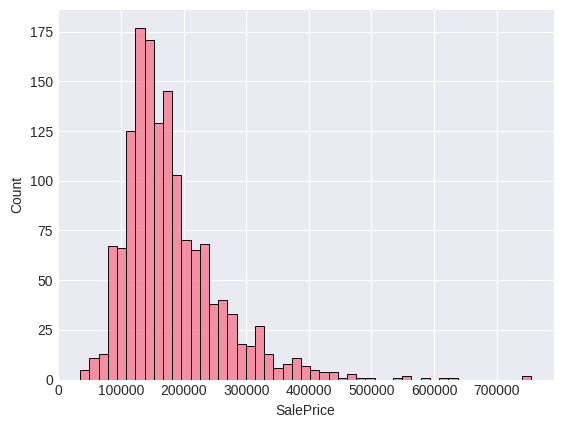

In [ ]:
sns.histplot(df_clean["SalePrice"])

Correlations visualization


In [ ]:
corr = df_clean.corr(numeric_only=True)

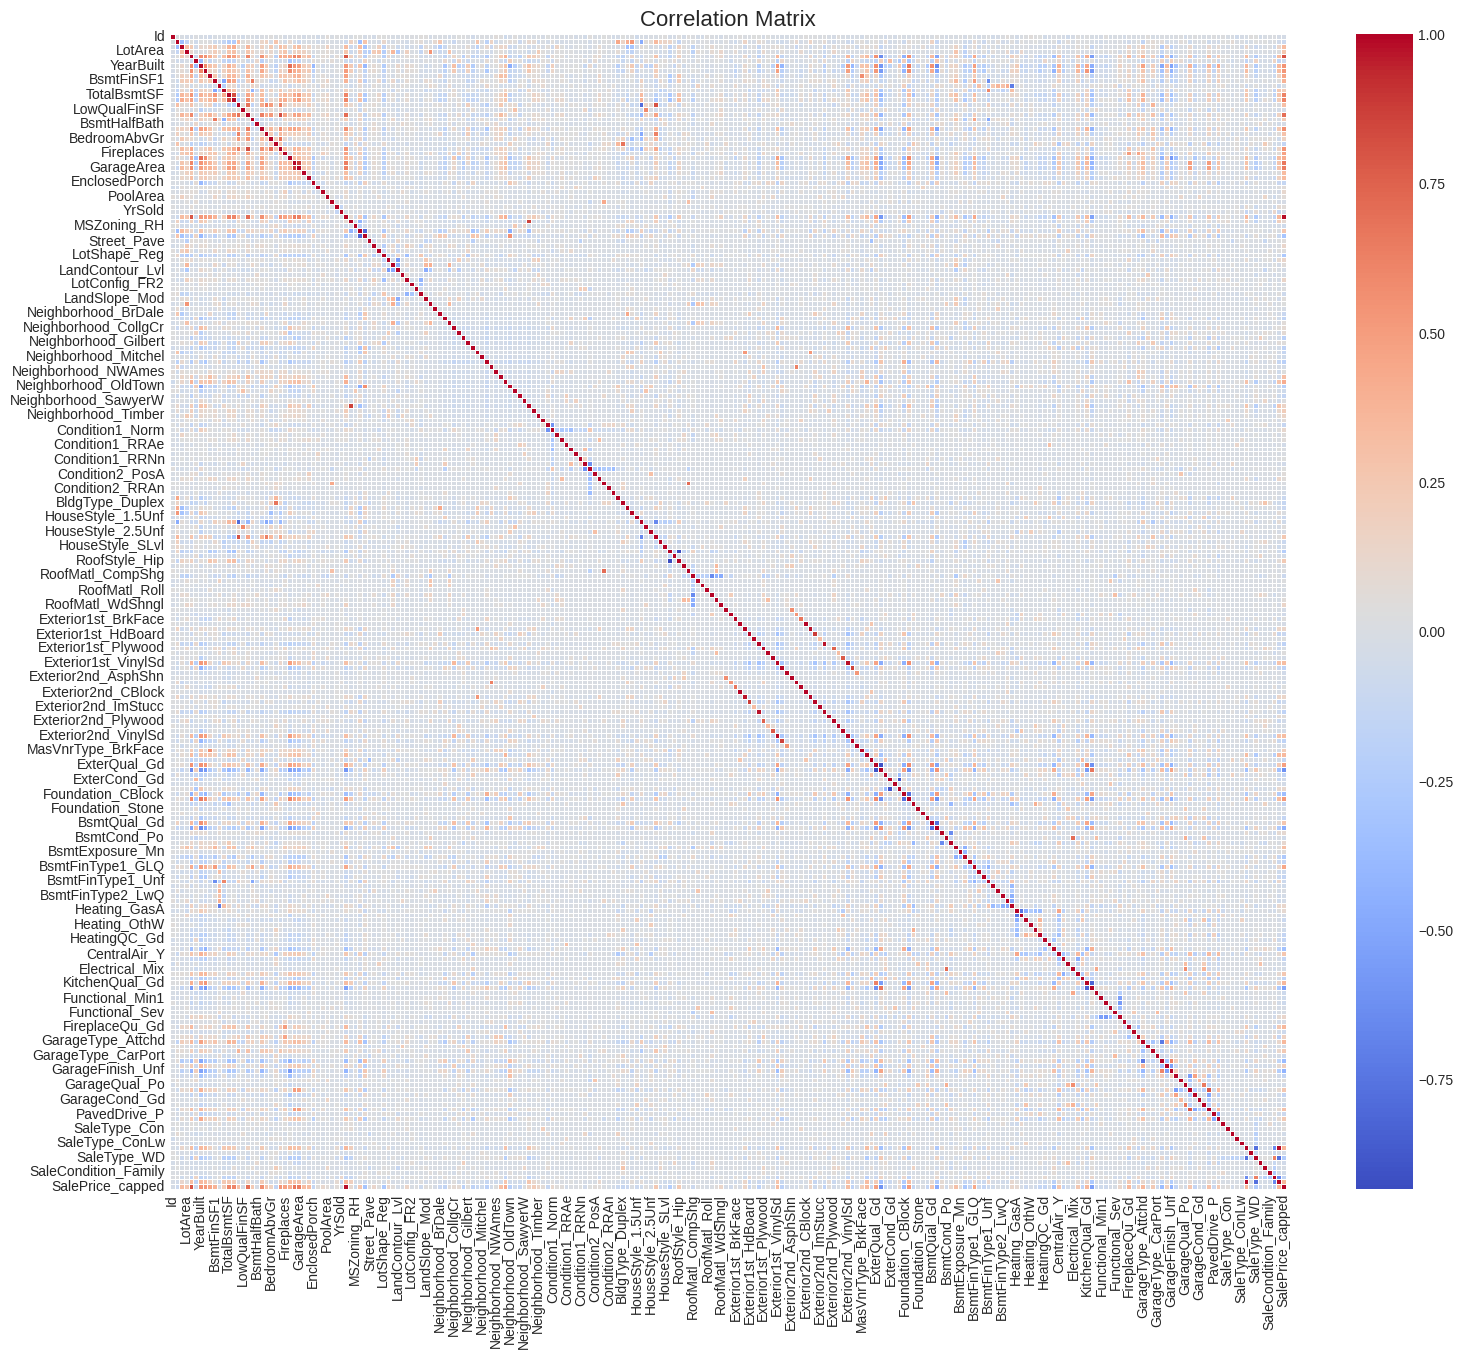

In [ ]:
plt.figure(figsize=(18, 15))
sns.heatmap(corr, cmap='coolwarm', annot=False, fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix', fontsize=16)
plt.show()

Identification of features X and Target Y


In [74]:
df_clean['HouseAge'] = df_clean['YrSold'] - df_clean['YearBuilt']
df_clean['YearsSinceRemod'] = df_clean['YrSold'] - df_clean['YearRemodAdd']
df_clean['TotalSF'] = df_clean['1stFlrSF'] + df_clean['2ndFlrSF'] + df_clean['TotalBsmtSF']
df_clean['TotalBath'] = df_clean['FullBath'] + (0.5 * df_clean['HalfBath']) + df_clean['BsmtFullBath'] + (0.5 * df_clean['BsmtHalfBath'])

X_features= [
    "OverallQual",
    "GrLivArea",
    "TotalBsmtSF",
    "1stFlrSF",
    "2ndFlrSF",
    "LotArea",
    "GarageArea",
    "GarageCars",
    "YearBuilt",
    "YearRemodAdd",
    "HouseAge",
    "YearsSinceRemod",
    "TotalSF",
    "TotalBath"
]

X = df_clean[X_features]
y = df_clean['SalePrice']

print("✓ Features prepared for machine learning")
print(f"\nFeature matrix shape: {X.shape}")
print(f"Target variable shape: {y.shape}")
print(f"\nFeatures used: {X_features}")

✓ Features prepared for machine learning

Feature matrix shape: (1460, 14)
Target variable shape: (1460,)

Features used: ['OverallQual', 'GrLivArea', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LotArea', 'GarageArea', 'GarageCars', 'YearBuilt', 'YearRemodAdd', 'HouseAge', 'YearsSinceRemod', 'TotalSF', 'TotalBath']


Train Test Split

In [79]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (1168, 14)
X_test: (292, 14)
y_train: (1168,)
y_test: (292,)


Linear Regression Model


In [80]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Premières prédictions :", y_pred[:5])
print("Vraies valeurs :", y_test[:5].values)

Premières prédictions : [145754.00528905 294010.35521078 109409.57970835 163304.12235031
 296793.37433405]
Vraies valeurs : [154500 325000 115000 159000 315500]


Model Evaluation with R2 and MSE

In [81]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("R²:", r2)

MSE: 1547812206.8874333
R²: 0.798207773036155
